In [1]:
import numpy as np
import matplotlib.pyplot as plt

from frenel import reflection_coeff_v2, get_interpolate

In [3]:
wl = 640e-9
w0 = 450e-9
f = wl/2

k1 = 2*np.pi / wl
rp, _ = reflection_coeff_v2(wl*1e9, get_interpolate('Au'), 0)
# rp = 0
absrp = np.abs(rp)

def c_i(z_t):
    return w0**2 - 2*1j*(z_t - f) / k1


def c_r(z_t):
    return w0**2 + 2*1j*(z_t + f) / k1


def ExiEzi(x, z):
    # x, _, z = point
    
    absci = np.abs(c_i(z))
    invci = 1 /c_i(z)

    m = - 2*1j * w0**2 * x /k1**3 /absci**3
    b = k1**2 * c_i(z) + 2*x**2 * invci - 1
    e = np.cos(2*x**2 * np.imag(invci)) - 1j * np.sin(2*x**2*np.imag(invci))

    return np.imag(m*b*e)


def ExiEzr(x, z):
    ci32 = c_i(z)**1.5
    cr32_cc = np.conj(c_r(z)**1.5)
    invci = 1 / c_i(z)
    invcr_cc = np.conj(1 / c_r(z))

    m = - 2*1j * w0**2 * x / k1**3 /ci32 /cr32_cc
    b = b = k1**2 * c_i(z) + 2*x**2 * invci - 1
    e = np.exp(x**2 * (invci - invcr_cc))

    return np.imag(np.conj(rp) * m * b * e)


def ExrEzi(x, z):
    cr32 = c_r(z)**1.5
    ci32_cc = np.conj(c_i(z)**1.5)
    invci_cc = np.conj(1 / c_i(z))
    invcr = 1 / c_r(z)

    m = - 2*1j * w0**2 * x / k1**3 /ci32_cc /cr32
    b = b = k1**2 * c_r(z) + 2*x**2 * invcr - 1
    e = np.exp(x**2 * (invcr - invci_cc))

    return np.imag(rp * m * b * e)


def ExrEzr(x, z):
    # x, _, z = point
    
    abscr = np.abs(c_r(z))
    invcr = 1 /c_r(z)

    m = - 2*1j * w0**2 * x /k1**3 /abscr**3
    b = k1**2 * c_r(z) + 2*x**2 * invcr - 1
    e = np.cos(2*x**2 * np.imag(invcr)) - 1j * np.sin(2*x**2*np.imag(invcr))

    return absrp**2*np.imag(m*b*e)


In [4]:
eps2 = get_interpolate('Au')(wl*1e9)
k2 = 2*np.pi / wl * np.sqrt(eps2 + 0j)

zeta = np.sqrt((eps2**2 * k1**2 - k2**2) /(eps2**2 - 1))

def dxGxz(x, z):
    b = k1**2 - zeta**2
    s = np.sqrt(b)
    e = np.exp(-2*1j*z*s)
    return np.imag(eps2**2 * b * zeta**2 / (2*k1**2 * (eps2**2 - 1)) * e)

In [21]:
nx, nz = 400, 1000

xmesh = np.linspace(-wl, wl, nx)
zmesh = np.linspace(-4*wl, 4*wl, nz)

vals = np.zeros((nz, nx))
for i in range(nx):
    for j in range(nz):
        x0, z0 = xmesh[i], zmesh[j]
        ii = ExiEzi(x0, z0)
        ir = ExiEzr(x0, z0)
        ri = ExrEzi(x0, z0)
        rr = ExrEzr(x0, z0)
        tot = ii + ir - ri - rr
        # dG = dxGxz(x0, z0)
        
        vals[j, i] = ir-ri

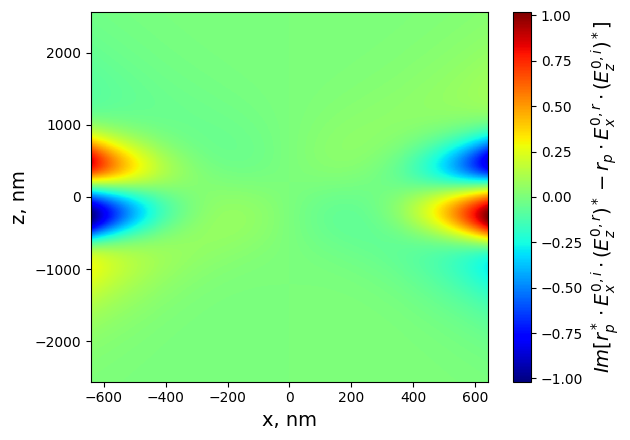

In [22]:
fig, ax = plt.subplots()
cmesh = ax.pcolormesh(1e9*xmesh, 1e9*zmesh, vals, cmap='jet')
cbar = plt.colorbar(cmesh, ax=ax)

# Im [ E_x^{0,i}\\cdot(E_z^{0,i})^*]
# -|r_p|^2 \\cdot Im [ E_x^{0,r}\\cdot(E_z^{0,r})^*]
# Im [r_p^* \\cdot E_x^{0,i}\\cdot(E_z^{0,r})^* - r_p \\cdot E_x^{0, r} \\cdot (E_z^{0, i})^*]

cbar.set_label('$Im [r_p^* \\cdot E_x^{0,i}\\cdot(E_z^{0,r})^* - r_p \\cdot E_x^{0, r} \\cdot (E_z^{0, i})^*]$', fontsize=14)
ax.set_xlabel('x, nm', fontsize=14)
ax.set_ylabel('z, nm', fontsize=14)
plt.savefig('/home/uspensky/Изображения/fields_prod_plots/ir_ri_4wl.png', dpi=200)